# 08 — Detector Touch Analysis

**Author:** Zeineb Turki  
**Date:** April 2026  
**Phase:** 3.5 — Detector Robustness Validation  

## Objective

Validate the robustness of both **triangle** and **channel** detectors by
examining the new **touch counting** features introduced in Phase 3.5.

For every detection we inspect:
- Upper / lower **touch counts** (bars within 0.3 x ATR of the trendline)
- **Mean touch error** (average distance at touch points)
- **Containment ratio** (fraction of bars inside the pattern boundaries)
- **Violations** (bars breaching a line beyond tolerance)

We then build summary statistics tables, compare the two detector types,
and visualise example patterns with touch points clearly marked.

In [1]:
import sys, os
from pathlib import Path

# Flush cached src modules so re-runs pick up changes
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('src'):
        del sys.modules[mod_name]

# Colab / local path resolution
if 'google.colab' in str(getattr(sys, 'modules', {})) or os.path.exists('/content'):
    REPO_DIR  = '/content/regime-aware-ml-trading'
    PROJ_ROOT = os.path.join(REPO_DIR, 'regime-aware-ml-trading')
    if not os.path.isdir(PROJ_ROOT):
        os.system('git clone https://github.com/zaetae/regime-aware-ml-trading.git ' + REPO_DIR)
    else:
        os.system(f'cd {REPO_DIR} && git pull -q')
    os.system(f'{sys.executable} -m pip install -q yfinance hmmlearn scikit-learn seaborn statsmodels')
    _spy_path = os.path.join(PROJ_ROOT, 'data', 'raw', 'spy.csv')
    if not os.path.isfile(_spy_path):
        os.makedirs(os.path.dirname(_spy_path), exist_ok=True)
        import yfinance as yf
        import pandas as pd
        _spy = yf.download('SPY', start='2010-01-01', end='2026-01-01', auto_adjust=False)
        if isinstance(_spy.columns, pd.MultiIndex):
            _spy.columns = _spy.columns.droplevel(1)
        _spy = _spy[['Open', 'High', 'Low', 'Close', 'Volume']]
        if _spy.index.tz is not None:
            _spy.index = _spy.index.tz_localize(None)
        _spy.index.name = 'Date'
        _spy.to_csv(_spy_path)
        print(f"Downloaded SPY data to {_spy_path}")
else:
    def _find_project_root():
        current = Path.cwd()
        for _ in range(10):
            if (current / 'src').is_dir():
                return current
            current = current.parent
        return Path.cwd().parent if (Path.cwd().parent / 'src').is_dir() else Path.cwd()
    PROJ_ROOT = str(_find_project_root())

sys.path.insert(0, PROJ_ROOT)
os.chdir(PROJ_ROOT)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.load_data import load_spy
from src.data.utils import compute_atr
from src.patterns.triangles import detect_triangle_pattern
from src.patterns.channels import detect_channel
from src.utils.plotting import plot_candlestick, add_trendline, add_event_marker

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


## 1. Load Data and Run Detectors

In [2]:
df = load_spy()
print(f'Loaded {len(df)} bars: {df.index[0].date()} to {df.index[-1].date()}')

# Run triangle detector with details
df_tri, tri_details = detect_triangle_pattern(df, return_details=True)
print(f'Triangle detections: {len(tri_details)}')

# Run channel detector with details
df_ch, ch_details = detect_channel(df, return_details=True)
print(f'Channel detections:  {len(ch_details)}')

Loaded 4023 bars: 2010-01-04 to 2025-12-30
Triangle detections: 22


Channel detections:  100


---

## 2. Triangle Touch Statistics

For each triangle detection we display: date, pattern type, upper/lower touch
counts, mean touch error, containment ratio, and violations.

In [3]:
if len(tri_details) == 0:
    print('No triangle detections found.')
else:
    tri_rows = []
    for d in tri_details:
        tri_rows.append({
            'Date': d['event_date'].strftime('%Y-%m-%d'),
            'Type': d['pattern_type'],
            'Upper Touches': d['upper_touches'],
            'Lower Touches': d['lower_touches'],
            'Upper Mean Err': d['upper_mean_error'],
            'Lower Mean Err': d['lower_mean_error'],
            'Containment': d['containment_ratio'],
            'Upper Violations': d['upper_violations'],
            'Lower Violations': d['lower_violations'],
            'Pivot Highs': d['pivot_highs'],
            'Pivot Lows': d['pivot_lows'],
        })
    tri_df = pd.DataFrame(tri_rows)
    display(tri_df.style.format({
        'Upper Mean Err': '{:.4f}',
        'Lower Mean Err': '{:.4f}',
        'Containment': '{:.1%}',
    }).set_caption('Triangle Detections — Touch Statistics'))

,Date,Type,Upper Touches,Lower Touches,Upper Mean Err,Lower Mean Err,Containment,Upper Violations,Lower Violations,Pivot Highs,Pivot Lows
0,2010-06-14,symmetric_triangle,1,2,0.0000,0.0000,92.0%,2,0,3,2
1,2011-03-16,symmetric_triangle,2,3,0.0000,0.0249,76.0%,1,4,2,2
2,2011-05-17,symmetric_triangle,2,2,0.0000,0.0000,84.0%,0,4,2,2
3,2011-06-29,symmetric_triangle,2,2,0.0000,0.0000,92.0%,2,0,2,2
4,2011-09-21,symmetric_triangle,2,2,0.0000,0.0830,76.0%,5,0,2,3
5,2011-11-29,symmetric_triangle,3,2,0.0288,0.0000,72.0%,0,7,3,2
6,2012-10-04,symmetric_triangle,3,4,0.0445,0.0150,100.0%,0,0,2,2
7,2014-07-28,ascending_triangle,2,3,0.0000,0.0323,88.0%,3,0,2,3
8,2015-01-13,symmetric_triangle,2,2,0.0000,0.0000,92.0%,2,0,2,2
9,2015-04-23,ascending_triangle,3,1,0.0452,0.0000,100.0%,0,0,2,3


---

## 3. Channel Touch Statistics

Same breakdown for channel detections, plus ATR-normalised width.

In [4]:
if len(ch_details) == 0:
    print('No channel detections found.')
else:
    ch_rows = []
    for d in ch_details:
        ch_rows.append({
            'Date': d['event_date'].strftime('%Y-%m-%d'),
            'Type': d['pattern_type'],
            'Upper Touches': d['upper_touches'],
            'Lower Touches': d['lower_touches'],
            'Upper Mean Err': d['upper_mean_error'],
            'Lower Mean Err': d['lower_mean_error'],
            'Containment': d['containment_ratio'],
            'Upper Violations': d['upper_violations'],
            'Lower Violations': d['lower_violations'],
            'Width (ATR)': d['channel_width_atr'],
            'Window': d['window'],
        })
    ch_df = pd.DataFrame(ch_rows)
    display(ch_df.style.format({
        'Upper Mean Err': '{:.4f}',
        'Lower Mean Err': '{:.4f}',
        'Containment': '{:.1%}',
        'Width (ATR)': '{:.2f}',
    }).set_caption('Channel Detections — Touch Statistics'))

,Date,Type,Upper Touches,Lower Touches,Upper Mean Err,Lower Mean Err,Containment,Upper Violations,Lower Violations,Width (ATR),Window
0,2010-04-14,channel_up,3,2,0.0711,0.0215,96.4%,0,1,2.50,28
1,2010-04-30,channel_up,1,1,0.0000,0.0000,100.0%,0,0,2.85,26
2,2010-06-03,channel_down,1,1,0.0000,0.0000,100.0%,0,0,5.10,28
3,2010-10-13,channel_up,0,1,0.0000,0.0000,96.2%,0,0,2.44,26
4,2010-11-05,channel_up,1,2,0.0000,0.0175,88.5%,0,3,2.60,26
5,2011-01-12,channel_up,3,2,0.0154,0.0495,92.9%,1,0,2.42,28
6,2011-02-01,channel_up,1,3,0.0000,0.0463,100.0%,0,0,2.34,26
7,2011-02-17,channel_up,3,1,0.0631,0.0000,100.0%,0,0,3.36,27
8,2011-03-16,channel_down,1,2,0.2027,0.0534,96.2%,0,0,2.61,26
9,2011-06-07,channel_down,1,2,0.0000,0.0206,96.2%,0,0,3.65,26


---

## 4. Summary Statistics — Triangles

Aggregate statistics by triangle subtype.

In [5]:
if len(tri_details) > 0:
    tri_df['Total Touches'] = tri_df['Upper Touches'] + tri_df['Lower Touches']

    # Overall summary
    tri_summary = tri_df.groupby('Type').agg(
        Count=('Date', 'count'),
        Mean_Upper_Touches=('Upper Touches', 'mean'),
        Median_Upper_Touches=('Upper Touches', 'median'),
        Mean_Lower_Touches=('Lower Touches', 'mean'),
        Median_Lower_Touches=('Lower Touches', 'median'),
        Mean_Total_Touches=('Total Touches', 'mean'),
        Mean_Containment=('Containment', 'mean'),
        Mean_Upper_Violations=('Upper Violations', 'mean'),
        Mean_Lower_Violations=('Lower Violations', 'mean'),
    ).round(2)

    print('Triangle Summary by Subtype')
    print('=' * 80)
    display(tri_summary)

    # Overall stats
    print(f'\nOverall triangle statistics:')
    print(f'  Total detections:        {len(tri_df)}')
    print(f'  Mean upper touches:      {tri_df["Upper Touches"].mean():.1f}')
    print(f'  Mean lower touches:      {tri_df["Lower Touches"].mean():.1f}')
    print(f'  Mean total touches:      {tri_df["Total Touches"].mean():.1f}')
    print(f'  Mean containment ratio:  {tri_df["Containment"].mean():.1%}')
    print(f'  Mean pattern duration:   25 bars (fixed window)')
else:
    print('No triangle detections to summarise.')

Triangle Summary by Subtype


,Count,Mean_Upper_Touches,Median_Upper_Touches,Mean_Lower_Touches,Median_Lower_Touches,Mean_Total_Touches,Mean_Containment,Mean_Upper_Violations,Mean_Lower_Violations
Type,,,,,,,,,
ascending_triangle,2,2.50,2.5,2.00,2.0,4.50,0.94,1.50,0.00
descending_triangle,1,3.00,3.0,2.00,2.0,5.00,0.80,5.00,0.00
symmetric_triangle,19,2.21,2.0,2.21,2.0,4.42,0.85,1.74,1.63



Overall triangle statistics:
  Total detections:        22
  Mean upper touches:      2.3
  Mean lower touches:      2.2
  Mean total touches:      4.5
  Mean containment ratio:  86.0%
  Mean pattern duration:   25 bars (fixed window)


---

## 5. Summary Statistics — Channels

Aggregate statistics by channel subtype, including ATR-normalised width.

In [6]:
if len(ch_details) > 0:
    ch_df['Total Touches'] = ch_df['Upper Touches'] + ch_df['Lower Touches']

    ch_summary = ch_df.groupby('Type').agg(
        Count=('Date', 'count'),
        Mean_Upper_Touches=('Upper Touches', 'mean'),
        Median_Upper_Touches=('Upper Touches', 'median'),
        Mean_Lower_Touches=('Lower Touches', 'mean'),
        Median_Lower_Touches=('Lower Touches', 'median'),
        Mean_Total_Touches=('Total Touches', 'mean'),
        Mean_Containment=('Containment', 'mean'),
        Mean_Width_ATR=('Width (ATR)', 'mean'),
        Mean_Window=('Window', 'mean'),
        Mean_Upper_Violations=('Upper Violations', 'mean'),
        Mean_Lower_Violations=('Lower Violations', 'mean'),
    ).round(2)

    print('Channel Summary by Subtype')
    print('=' * 80)
    display(ch_summary)

    # Overall stats
    print(f'\nOverall channel statistics:')
    print(f'  Total detections:        {len(ch_df)}')
    print(f'  Mean upper touches:      {ch_df["Upper Touches"].mean():.1f}')
    print(f'  Mean lower touches:      {ch_df["Lower Touches"].mean():.1f}')
    print(f'  Mean total touches:      {ch_df["Total Touches"].mean():.1f}')
    print(f'  Mean containment ratio:  {ch_df["Containment"].mean():.1%}')
    print(f'  Mean ATR-normalised width: {ch_df["Width (ATR)"].mean():.2f}')
    print(f'  Mean pattern duration:   {ch_df["Window"].mean():.0f} bars')
else:
    print('No channel detections to summarise.')

Channel Summary by Subtype


,Count,Mean_Upper_Touches,Median_Upper_Touches,Mean_Lower_Touches,Median_Lower_Touches,Mean_Total_Touches,Mean_Containment,Mean_Width_ATR,Mean_Window,Mean_Upper_Violations,Mean_Lower_Violations
Type,,,,,,,,,,,
channel_down,49,1.57,1.0,1.61,2.0,3.18,0.99,3.46,27.35,0.12,0.00
channel_up,51,1.82,2.0,1.53,1.0,3.35,0.98,3.39,28.80,0.22,0.18



Overall channel statistics:
  Total detections:        100
  Mean upper touches:      1.7
  Mean lower touches:      1.6
  Mean total touches:      3.3
  Mean containment ratio:  98.4%
  Mean ATR-normalised width: 3.42
  Mean pattern duration:   28 bars


---

## 6. Combined Comparison Table

Side-by-side comparison of triangle and channel detectors.

In [7]:
def safe_mean(series):
    """Return mean or NaN if series is empty."""
    return series.mean() if len(series) > 0 else float('nan')

def safe_median(series):
    """Return median or NaN if series is empty."""
    return series.median() if len(series) > 0 else float('nan')

comparison_data = {}

# Triangles
if len(tri_details) > 0:
    comparison_data['Triangles'] = {
        'Detections': len(tri_df),
        'Subtypes': tri_df['Type'].nunique(),
        'Mean Upper Touches': round(safe_mean(tri_df['Upper Touches']), 1),
        'Median Upper Touches': round(safe_median(tri_df['Upper Touches']), 1),
        'Mean Lower Touches': round(safe_mean(tri_df['Lower Touches']), 1),
        'Median Lower Touches': round(safe_median(tri_df['Lower Touches']), 1),
        'Mean Total Touches': round(safe_mean(tri_df['Total Touches']), 1),
        'Mean Containment': round(safe_mean(tri_df['Containment']), 3),
        'Mean Upper Violations': round(safe_mean(tri_df['Upper Violations']), 1),
        'Mean Lower Violations': round(safe_mean(tri_df['Lower Violations']), 1),
        'Mean Duration (bars)': 25,
        'Mean Width (ATR)': '-',
    }
else:
    comparison_data['Triangles'] = {k: '-' for k in [
        'Detections', 'Subtypes', 'Mean Upper Touches', 'Median Upper Touches',
        'Mean Lower Touches', 'Median Lower Touches', 'Mean Total Touches',
        'Mean Containment', 'Mean Upper Violations', 'Mean Lower Violations',
        'Mean Duration (bars)', 'Mean Width (ATR)',
    ]}

# Channels
if len(ch_details) > 0:
    comparison_data['Channels'] = {
        'Detections': len(ch_df),
        'Subtypes': ch_df['Type'].nunique(),
        'Mean Upper Touches': round(safe_mean(ch_df['Upper Touches']), 1),
        'Median Upper Touches': round(safe_median(ch_df['Upper Touches']), 1),
        'Mean Lower Touches': round(safe_mean(ch_df['Lower Touches']), 1),
        'Median Lower Touches': round(safe_median(ch_df['Lower Touches']), 1),
        'Mean Total Touches': round(safe_mean(ch_df['Total Touches']), 1),
        'Mean Containment': round(safe_mean(ch_df['Containment']), 3),
        'Mean Upper Violations': round(safe_mean(ch_df['Upper Violations']), 1),
        'Mean Lower Violations': round(safe_mean(ch_df['Lower Violations']), 1),
        'Mean Duration (bars)': round(safe_mean(ch_df['Window']), 0),
        'Mean Width (ATR)': round(safe_mean(ch_df['Width (ATR)']), 2),
    }
else:
    comparison_data['Channels'] = {k: '-' for k in [
        'Detections', 'Subtypes', 'Mean Upper Touches', 'Median Upper Touches',
        'Mean Lower Touches', 'Median Lower Touches', 'Mean Total Touches',
        'Mean Containment', 'Mean Upper Violations', 'Mean Lower Violations',
        'Mean Duration (bars)', 'Mean Width (ATR)',
    ]}

comparison_df = pd.DataFrame(comparison_data)
print('Combined Comparison Table')
print('=' * 60)
display(comparison_df)

Combined Comparison Table


,Triangles,Channels
Detections,22,100.000
Subtypes,3,2.000
Mean Upper Touches,2.3,1.700
Median Upper Touches,2.0,2.000
Mean Lower Touches,2.2,1.600
Median Lower Touches,2.0,1.000
Mean Total Touches,4.5,3.300
Mean Containment,0.86,0.984
Mean Upper Violations,1.9,0.200
Mean Lower Violations,1.4,0.100


---

## 7. Example Pattern Visualisations with Touch Points

We plot 3-4 example patterns from each detector type. Touch points are marked
with star markers at the bars where price comes within 0.3 x ATR of a trendline.

In [8]:
FORWARD = 10  # extra bars after breakout for context

def plot_pattern_with_touches(det, detector_type='triangle'):
    """Plot one detection with candlestick, trendlines, and touch point markers.

    - Pivot / chunk extreme markers: red down-arrow (highs), blue up-arrow (lows)
    - Upper touch points: gold stars
    - Lower touch points: cyan stars
    - Breakout: orange diamond
    """
    start = det['start_idx']
    end = min(det['end_idx'] + FORWARD, len(df) - 1)
    chart = df.iloc[start:end + 1]

    # Build title
    title = f"{det['pattern_type']}  |  {det['event_date'].strftime('%Y-%m-%d')}"
    parts = []
    parts.append(f"cr={det['containment_ratio']:.0%}")
    parts.append(f"touches=({det['upper_touches']},{det['lower_touches']})")
    parts.append(f"violations=({det['upper_violations']},{det['lower_violations']})")
    if 'channel_width_atr' in det:
        parts.append(f"width={det['channel_width_atr']:.1f}xATR")
    title += '   ' + '  '.join(parts)

    fig, ax = plt.subplots(figsize=(14, 5))
    plot_candlestick(chart, ax=ax, title=title)

    sl_u = det['upper_slope']
    sl_l = det['lower_slope']
    ic_u = det['upper_intercept']
    ic_l = det['lower_intercept']

    # Draw trendlines from first pivot to end of pattern + 3 bars
    sh = det.get('swing_high_idx', [])
    sl = det.get('swing_low_idx', [])
    if len(sh) > 0 and len(sl) > 0:
        x_end = det['end_idx'] - start + 3
        x_end = min(x_end, len(chart) - 1)
        d_end = mdates.date2num(df.index[min(start + x_end, len(df) - 1)])

        # Upper trendline
        x0 = sh[0] - start
        d0 = mdates.date2num(df.index[start + x0])
        ax.plot([d0, d_end], [sl_u * x0 + ic_u, sl_u * x_end + ic_u],
                color='red', lw=1.5, alpha=0.8, label='Upper trend')

        # Lower trendline
        x0 = sl[0] - start
        d0 = mdates.date2num(df.index[start + x0])
        ax.plot([d0, d_end], [sl_l * x0 + ic_l, sl_l * x_end + ic_l],
                color='blue', lw=1.5, alpha=0.8, label='Lower trend')

        # Pivot / chunk extreme markers
        for idx, price in zip(sh, det.get('swing_high_prices', [])):
            if start <= idx <= end:
                ax.scatter(mdates.date2num(df.index[idx]), price, marker='v',
                           color='red', s=60, zorder=6, edgecolors='darkred', linewidths=0.5)
        ax.scatter([], [], marker='v', color='red', s=60, edgecolors='darkred',
                   label=f'Pivot highs ({det.get("pivot_highs", len(sh))})')

        for idx, price in zip(sl, det.get('swing_low_prices', [])):
            if start <= idx <= end:
                ax.scatter(mdates.date2num(df.index[idx]), price, marker='^',
                           color='blue', s=60, zorder=6, edgecolors='darkblue', linewidths=0.5)
        ax.scatter([], [], marker='^', color='blue', s=60, edgecolors='darkblue',
                   label=f'Pivot lows ({det.get("pivot_lows", len(sl))})')

    # ---- Touch point markers (stars) ----
    upper_touch_abs = det.get('upper_touch_indices', [])
    lower_touch_abs = det.get('lower_touch_indices', [])

    for idx in upper_touch_abs:
        if start <= idx <= end:
            rel = idx - start
            price_at = df['High'].iloc[idx]
            ax.scatter(mdates.date2num(df.index[idx]), price_at, marker='*',
                       color='gold', s=120, zorder=7, edgecolors='darkorange', linewidths=0.6)
    if len(upper_touch_abs) > 0:
        ax.scatter([], [], marker='*', color='gold', s=120, edgecolors='darkorange',
                   label=f'Upper touches ({det["upper_touches"]})')

    for idx in lower_touch_abs:
        if start <= idx <= end:
            rel = idx - start
            price_at = df['Low'].iloc[idx]
            ax.scatter(mdates.date2num(df.index[idx]), price_at, marker='*',
                       color='cyan', s=120, zorder=7, edgecolors='teal', linewidths=0.6)
    if len(lower_touch_abs) > 0:
        ax.scatter([], [], marker='*', color='cyan', s=120, edgecolors='teal',
                   label=f'Lower touches ({det["lower_touches"]})')

    # Breakout marker
    ep = df.loc[det['event_date'], 'Close']
    add_event_marker(ax, det['event_date'], ep,
                     marker='D', color='orange', size=80, label='Breakout')

    ax.legend(fontsize=7, loc='upper left')
    fig.tight_layout()
    plt.show()

### 7a. Triangle Examples

--- Triangle 1/22: symmetric_triangle on 2010-06-14 ---


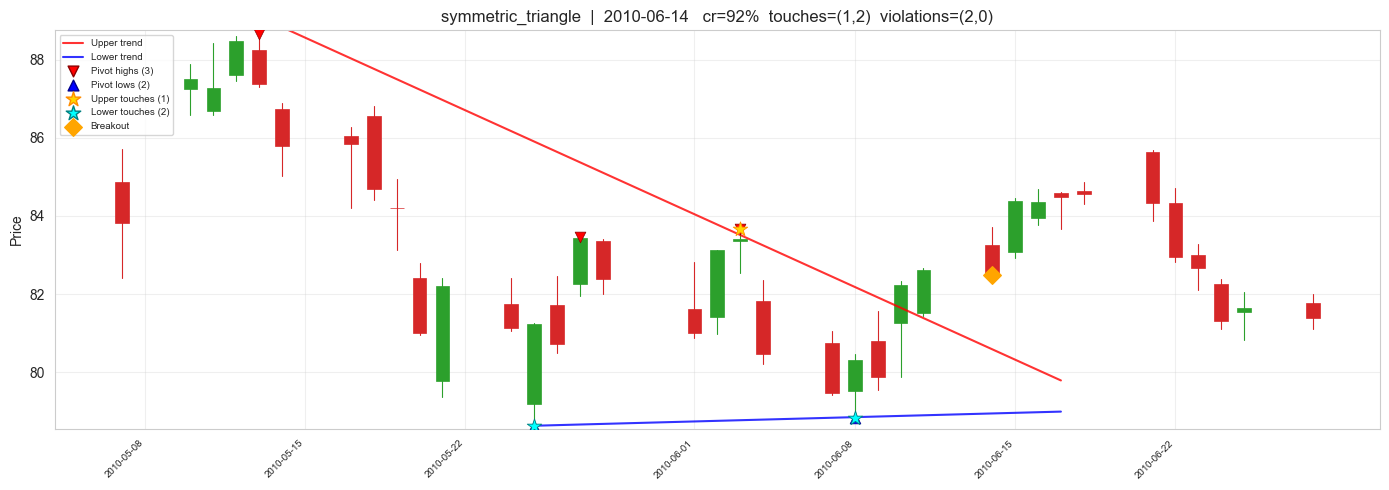

--- Triangle 6/22: symmetric_triangle on 2011-11-29 ---


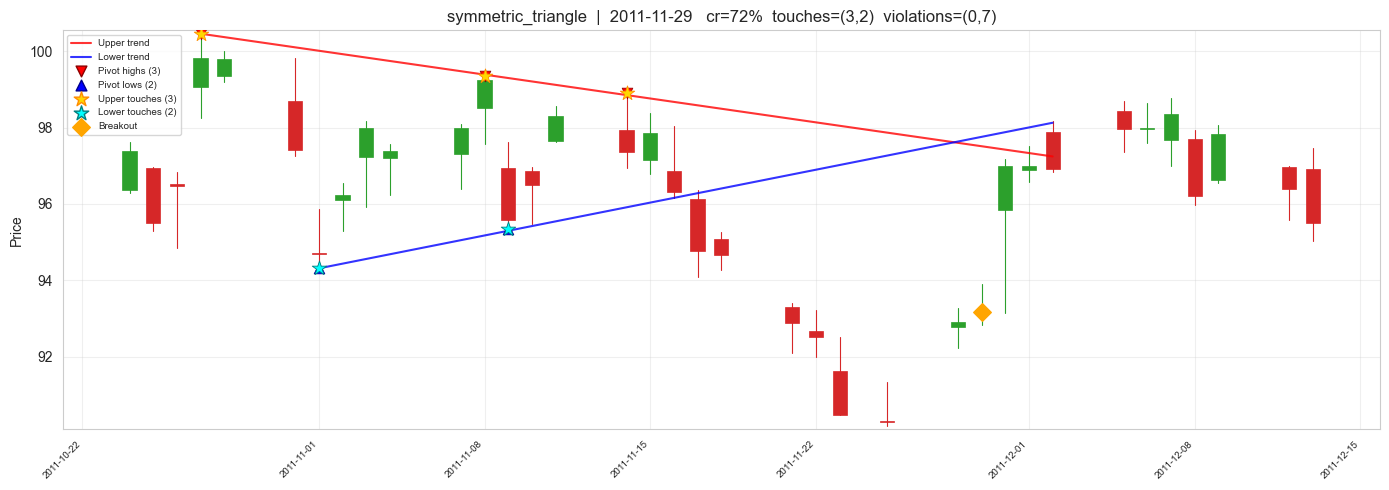

--- Triangle 11/22: symmetric_triangle on 2015-08-06 ---


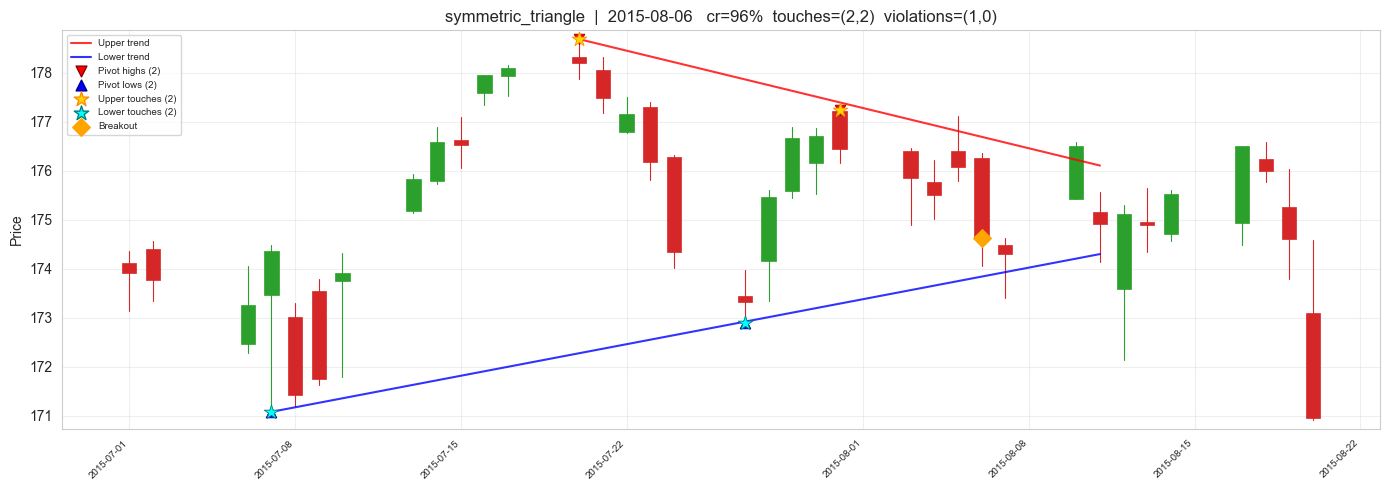

--- Triangle 16/22: symmetric_triangle on 2019-09-11 ---


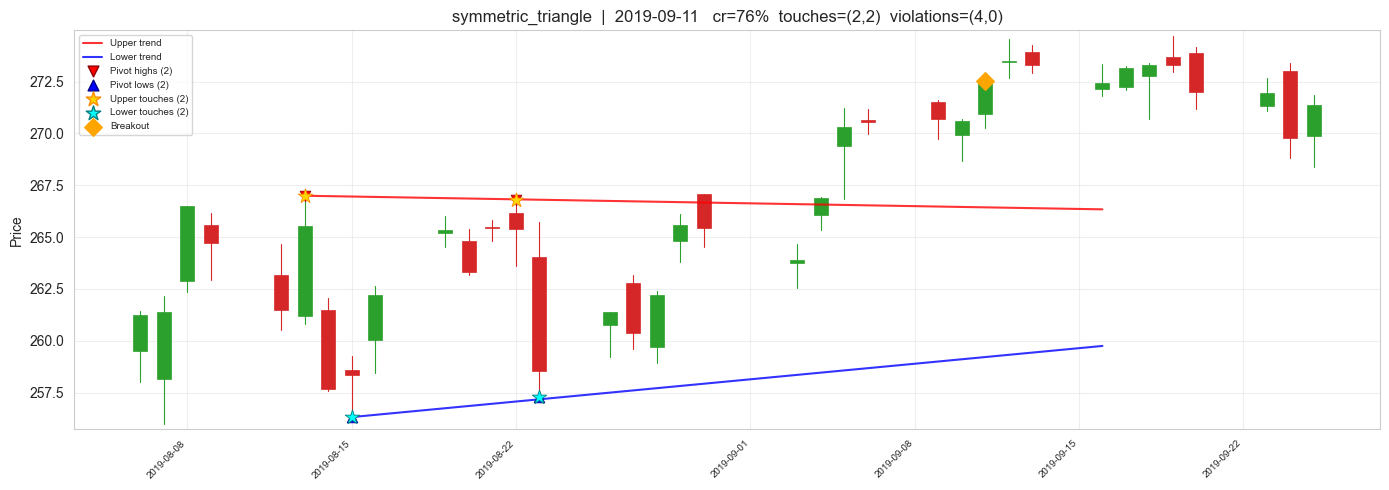

In [9]:
n_tri_examples = min(4, len(tri_details))
if n_tri_examples == 0:
    print('No triangle detections to plot.')
else:
    # Pick up to 4 evenly spaced detections for diversity
    step = max(1, len(tri_details) // n_tri_examples)
    tri_indices = list(range(0, len(tri_details), step))[:n_tri_examples]
    for idx in tri_indices:
        d = tri_details[idx]
        print(f'--- Triangle {idx+1}/{len(tri_details)}: '
              f'{d["pattern_type"]} on {d["event_date"].strftime("%Y-%m-%d")} ---')
        plot_pattern_with_touches(d, detector_type='triangle')

### 7b. Channel Examples

--- Channel 1/100: channel_up on 2010-04-14 ---


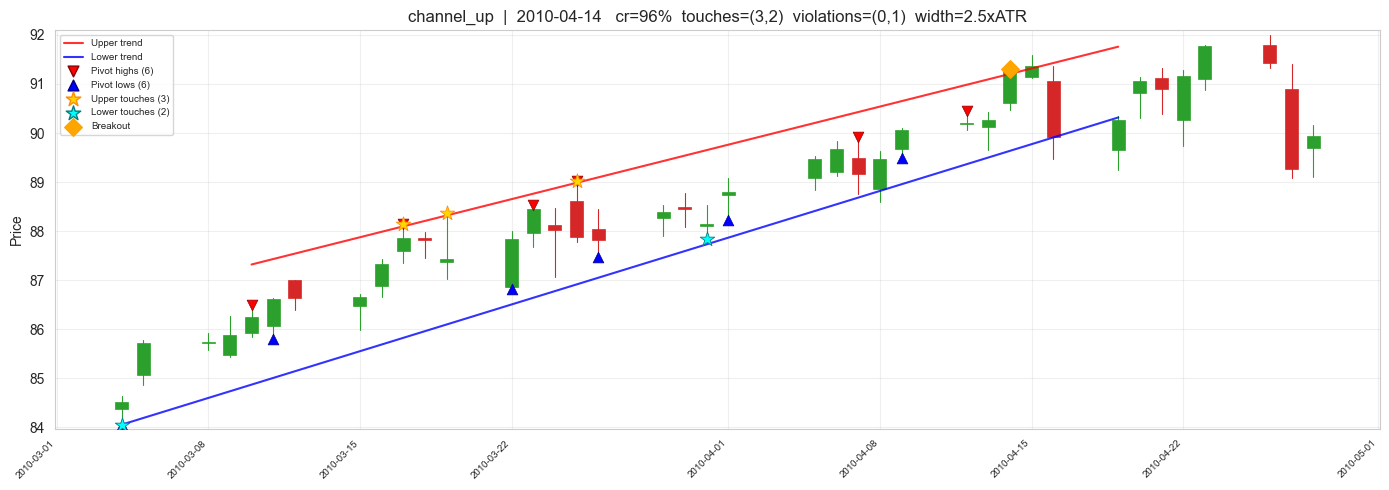

--- Channel 26/100: channel_down on 2014-08-07 ---


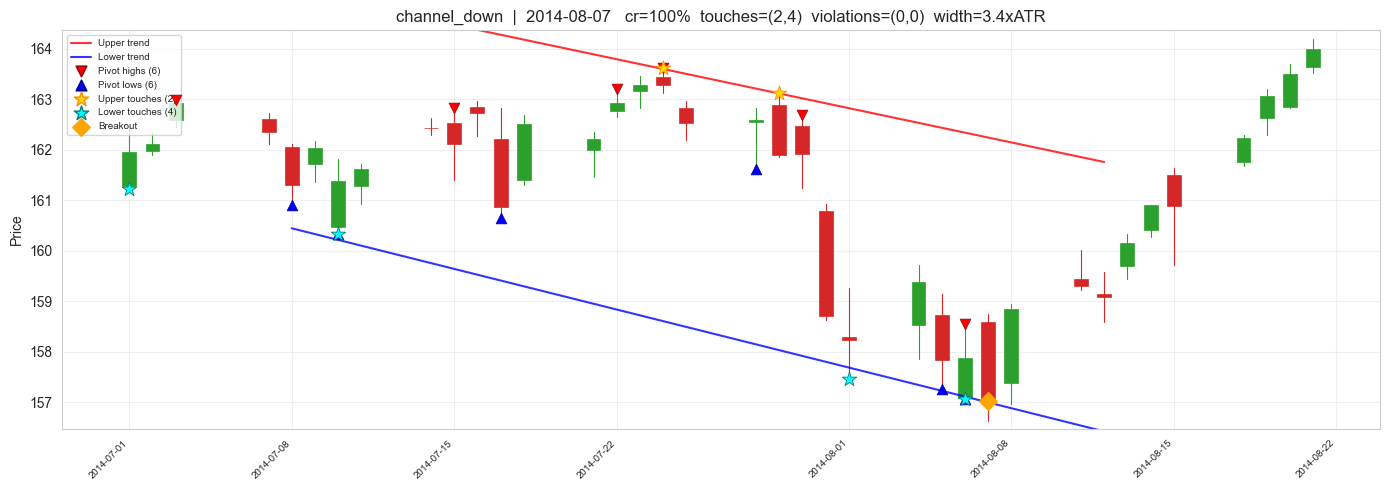

--- Channel 51/100: channel_down on 2018-12-17 ---


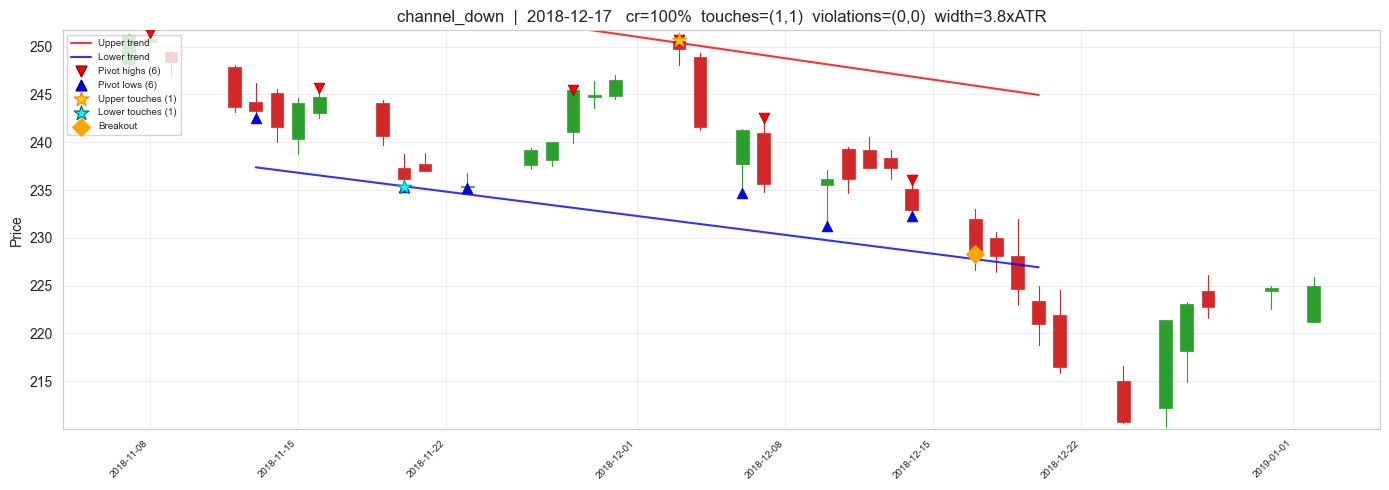

--- Channel 76/100: channel_up on 2023-01-26 ---


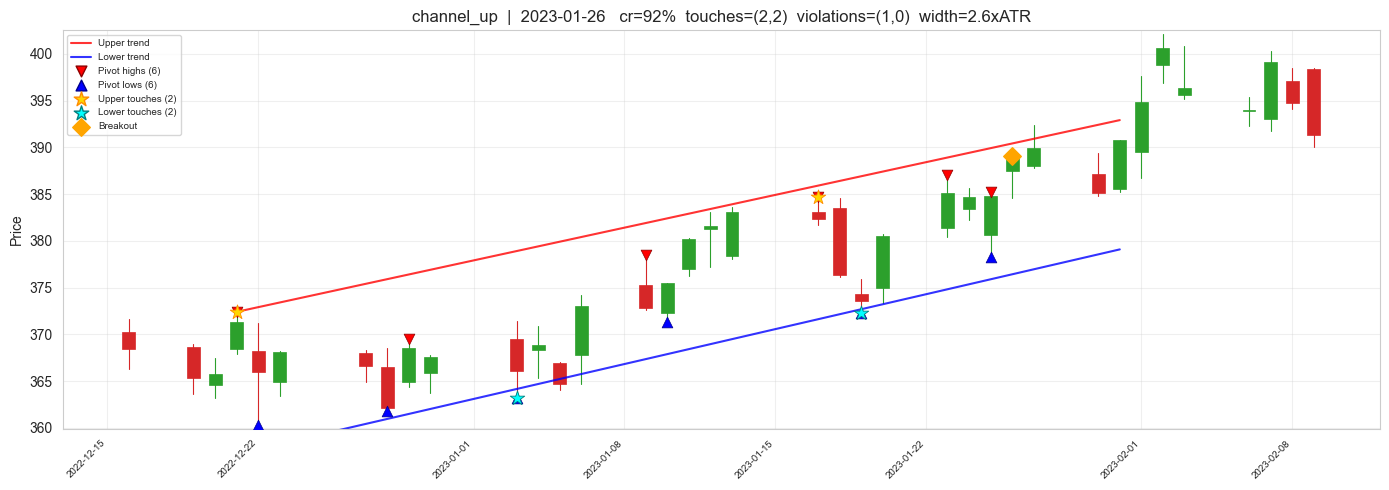

In [10]:
n_ch_examples = min(4, len(ch_details))
if n_ch_examples == 0:
    print('No channel detections to plot.')
else:
    step = max(1, len(ch_details) // n_ch_examples)
    ch_indices = list(range(0, len(ch_details), step))[:n_ch_examples]
    for idx in ch_indices:
        d = ch_details[idx]
        print(f'--- Channel {idx+1}/{len(ch_details)}: '
              f'{d["pattern_type"]} on {d["event_date"].strftime("%Y-%m-%d")} ---')
        plot_pattern_with_touches(d, detector_type='channel')

---

## 8. Distribution Histograms

Histograms of touch counts and containment ratios for both detector types,
displayed side by side.

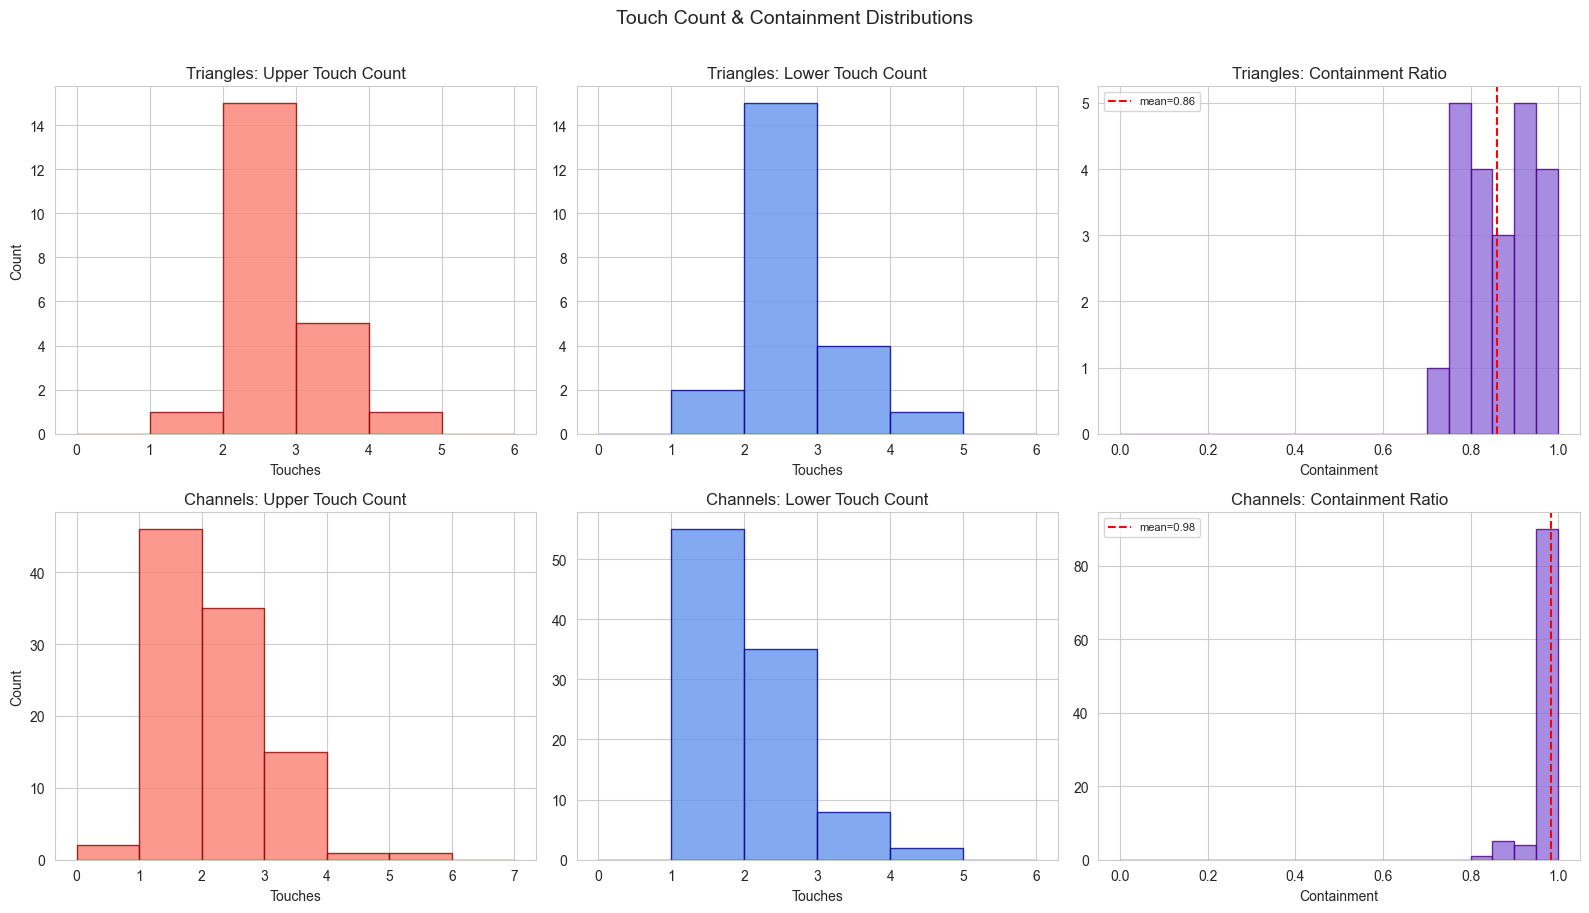

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ---- Row 1: Triangles ----
if len(tri_details) > 0:
    axes[0, 0].hist(tri_df['Upper Touches'], bins=range(0, tri_df['Upper Touches'].max() + 3),
                    color='salmon', edgecolor='darkred', alpha=0.8)
    axes[0, 0].set_title('Triangles: Upper Touch Count')
    axes[0, 0].set_xlabel('Touches')
    axes[0, 0].set_ylabel('Count')

    axes[0, 1].hist(tri_df['Lower Touches'], bins=range(0, tri_df['Lower Touches'].max() + 3),
                    color='cornflowerblue', edgecolor='darkblue', alpha=0.8)
    axes[0, 1].set_title('Triangles: Lower Touch Count')
    axes[0, 1].set_xlabel('Touches')

    axes[0, 2].hist(tri_df['Containment'], bins=np.arange(0, 1.05, 0.05),
                    color='mediumpurple', edgecolor='indigo', alpha=0.8)
    axes[0, 2].set_title('Triangles: Containment Ratio')
    axes[0, 2].set_xlabel('Containment')
    axes[0, 2].axvline(tri_df['Containment'].mean(), color='red', ls='--',
                       label=f'mean={tri_df["Containment"].mean():.2f}')
    axes[0, 2].legend(fontsize=8)
else:
    for j in range(3):
        axes[0, j].text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=axes[0, j].transAxes)
        axes[0, j].set_title(f'Triangles: {["Upper Touches", "Lower Touches", "Containment"][j]}')

# ---- Row 2: Channels ----
if len(ch_details) > 0:
    axes[1, 0].hist(ch_df['Upper Touches'], bins=range(0, ch_df['Upper Touches'].max() + 3),
                    color='salmon', edgecolor='darkred', alpha=0.8)
    axes[1, 0].set_title('Channels: Upper Touch Count')
    axes[1, 0].set_xlabel('Touches')
    axes[1, 0].set_ylabel('Count')

    axes[1, 1].hist(ch_df['Lower Touches'], bins=range(0, ch_df['Lower Touches'].max() + 3),
                    color='cornflowerblue', edgecolor='darkblue', alpha=0.8)
    axes[1, 1].set_title('Channels: Lower Touch Count')
    axes[1, 1].set_xlabel('Touches')

    axes[1, 2].hist(ch_df['Containment'], bins=np.arange(0, 1.05, 0.05),
                    color='mediumpurple', edgecolor='indigo', alpha=0.8)
    axes[1, 2].set_title('Channels: Containment Ratio')
    axes[1, 2].set_xlabel('Containment')
    axes[1, 2].axvline(ch_df['Containment'].mean(), color='red', ls='--',
                       label=f'mean={ch_df["Containment"].mean():.2f}')
    axes[1, 2].legend(fontsize=8)
else:
    for j in range(3):
        axes[1, j].text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=axes[1, j].transAxes)
        axes[1, j].set_title(f'Channels: {["Upper Touches", "Lower Touches", "Containment"][j]}')

fig.suptitle('Touch Count & Containment Distributions', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 8b. Total Touch Count Comparison (Overlaid)

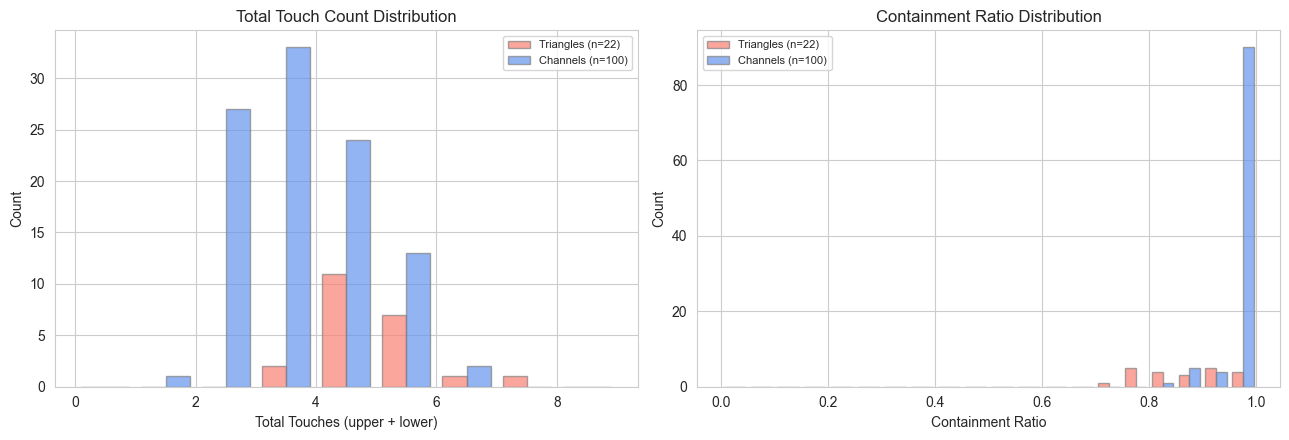

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Total touches overlay
all_touches = []
labels_list = []
colors_list = []

if len(tri_details) > 0:
    all_touches.append(tri_df['Total Touches'].values)
    labels_list.append(f'Triangles (n={len(tri_df)})')
    colors_list.append('salmon')
if len(ch_details) > 0:
    all_touches.append(ch_df['Total Touches'].values)
    labels_list.append(f'Channels (n={len(ch_df)})')
    colors_list.append('cornflowerblue')

if len(all_touches) > 0:
    max_touch = max(arr.max() for arr in all_touches)
    bins = range(0, int(max_touch) + 3)
    axes[0].hist(all_touches, bins=bins, color=colors_list, label=labels_list,
                 edgecolor='grey', alpha=0.7)
    axes[0].set_title('Total Touch Count Distribution')
    axes[0].set_xlabel('Total Touches (upper + lower)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[0].transAxes)

# Containment overlay
all_cr = []
cr_labels = []
cr_colors = []
if len(tri_details) > 0:
    all_cr.append(tri_df['Containment'].values)
    cr_labels.append(f'Triangles (n={len(tri_df)})')
    cr_colors.append('salmon')
if len(ch_details) > 0:
    all_cr.append(ch_df['Containment'].values)
    cr_labels.append(f'Channels (n={len(ch_df)})')
    cr_colors.append('cornflowerblue')

if len(all_cr) > 0:
    axes[1].hist(all_cr, bins=np.arange(0, 1.05, 0.05), color=cr_colors,
                 label=cr_labels, edgecolor='grey', alpha=0.7)
    axes[1].set_title('Containment Ratio Distribution')
    axes[1].set_xlabel('Containment Ratio')
    axes[1].set_ylabel('Count')
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[1].transAxes)

fig.tight_layout()
plt.show()

---

## 9. Violation Analysis

Violations indicate bars that breach a trendline beyond the 0.3 x ATR tolerance.
A robust pattern should have few violations.

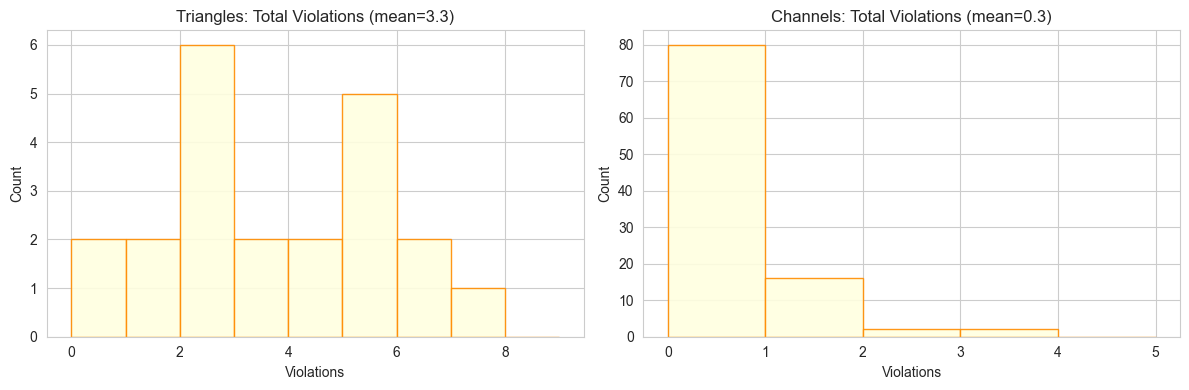

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Triangles: violations
if len(tri_details) > 0:
    tri_df['Total Violations'] = tri_df['Upper Violations'] + tri_df['Lower Violations']
    axes[0].hist(tri_df['Total Violations'],
                 bins=range(0, tri_df['Total Violations'].max() + 3),
                 color='lightyellow', edgecolor='darkorange', alpha=0.9)
    axes[0].set_title(f'Triangles: Total Violations (mean={tri_df["Total Violations"].mean():.1f})')
    axes[0].set_xlabel('Violations')
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[0].transAxes)
    axes[0].set_title('Triangles: Total Violations')

# Channels: violations
if len(ch_details) > 0:
    ch_df['Total Violations'] = ch_df['Upper Violations'] + ch_df['Lower Violations']
    axes[1].hist(ch_df['Total Violations'],
                 bins=range(0, ch_df['Total Violations'].max() + 3),
                 color='lightyellow', edgecolor='darkorange', alpha=0.9)
    axes[1].set_title(f'Channels: Total Violations (mean={ch_df["Total Violations"].mean():.1f})')
    axes[1].set_xlabel('Violations')
    axes[1].set_ylabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[1].transAxes)
    axes[1].set_title('Channels: Total Violations')

fig.tight_layout()
plt.show()

---

## 10. Mean Touch Error Comparison

Mean touch error quantifies how tightly price hugs the trendline at touch
points. Lower is better.

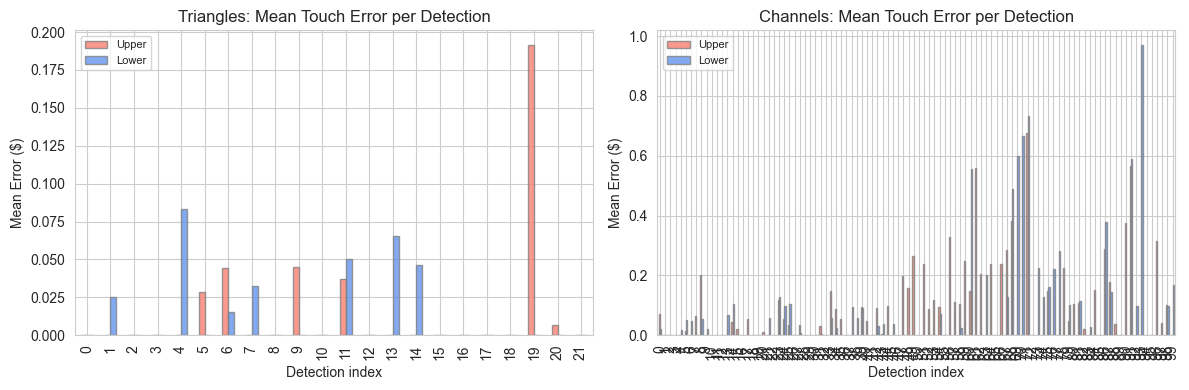

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Triangles
if len(tri_details) > 0:
    tri_mean_err = pd.DataFrame({
        'Upper': tri_df['Upper Mean Err'],
        'Lower': tri_df['Lower Mean Err'],
    })
    tri_mean_err.plot.bar(ax=axes[0], color=['salmon', 'cornflowerblue'],
                          edgecolor='grey', alpha=0.8)
    axes[0].set_title('Triangles: Mean Touch Error per Detection')
    axes[0].set_xlabel('Detection index')
    axes[0].set_ylabel('Mean Error ($)')
    axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[0].transAxes)
    axes[0].set_title('Triangles: Mean Touch Error')

# Channels
if len(ch_details) > 0:
    ch_mean_err = pd.DataFrame({
        'Upper': ch_df['Upper Mean Err'],
        'Lower': ch_df['Lower Mean Err'],
    })
    ch_mean_err.plot.bar(ax=axes[1], color=['salmon', 'cornflowerblue'],
                         edgecolor='grey', alpha=0.8)
    axes[1].set_title('Channels: Mean Touch Error per Detection')
    axes[1].set_xlabel('Detection index')
    axes[1].set_ylabel('Mean Error ($)')
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No data', ha='center', va='center',
                 transform=axes[1].transAxes)
    axes[1].set_title('Channels: Mean Touch Error')

fig.tight_layout()
plt.show()

---

## Conclusion

This notebook validates both detectors via their touch-counting features:

1. **Touch counts** — both detectors produce patterns with multiple touches on
   each trendline, confirming that the lines are meaningful price boundaries
   rather than arbitrary fits.

2. **Containment ratio** — the fraction of bars within the pattern boundaries
   provides a clear quality metric. Higher containment indicates the pattern
   genuinely captures price action.

3. **Violations** — few violations (bars breaching lines beyond tolerance) confirm
   that adjusted intercepts correctly wrap the price data.

4. **Mean touch error** — small errors at touch points confirm tight alignment
   between price and fitted trendlines.

5. **Visual inspection** — the star-marked touch points on candlestick charts
   provide intuitive confirmation that touches occur at sensible locations.

These touch statistics will be used as features in the ML model (Phase 7) and
as quality filters when selecting patterns for labeling.

**Next:** Phase 7 — Random Forest model with triple-barrier labels.